# Przegląd oraz czyszczenie danych 

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_rows', 100)

In [3]:
dane_epsg2180_lublin = gpd.read_file("data/dane_epsg2180_lublin.gml", encoding="UTF-8")

In [4]:
dane_epsg2180_lublin.head()

,gml_id,serwis_rcn,teryt,tran_przestrzen_nazw,tran_lokalny_id_iip,tran_wersja_id,tran_rodzaj_trans,tran_rodzaj_rynku,tran_sprzedajacy,tran_kupujacy,tran_cena_brutto,tran_vat,dok_data,nier_rodzaj,nier_prawo,nier_udzial,nier_pow_gruntu,nier_cena_brutto,nier_vat,lok_id_lokalu,lok_nr_lokalu,lok_funkcja,lok_liczba_izb,lok_nr_kond,lok_pow_uzyt,lok_pow_przyn,lok_cena_brutto,lok_vat,lok_adres,dzielnica,geometry
0,lokale.7761778,None,0663,PL.PZGiK.4884.RCN,489235f9-11ae-4ad4-9e02-c7d5de4e955f,2025-02-17T09:45:21,wolnyRynek,wtorny,osobaFizyczna,osobaPrawna,327000,24222.22,2025-01-28 00:00:00+00:00,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,656,327000,24222.22,066301_1.0019.AR_9.5/6.1_BUD.7_LOK,7_LOK,mieszkalna,3,1,45.1,NaN,NaN,NaN,MSC:Lublin;UL:Sowia;NR_PORZ:1,Bronowice,POINT (750558.696 380348.746)
1,lokale.7766269,None,0663,PL.PZGiK.4884.RCN,d861fefd-4d61-4dfe-9428-a1eb9cd289e0,2025-08-13T09:33:01,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,401702.81,29755.76,2025-07-25 00:00:00+00:00,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,8787,401702.81,29755.76,066301_1.0004.AR_3.15/7.1_BUD.71_LOK,71_LOK,mieszkalna,2,4,33.59,NaN,NaN,NaN,MSC:Lublin;UL:Mirosława Dereckiego;NR_PORZ:13,Czechów Pł.,POINT (746892.793 385137.992)
2,lokale.7765672,None,0663,PL.PZGiK.4884.RCN,898950a5-338e-422c-9863-158d9a6cc814,2025-09-11T09:28:18,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,443920,32882.96,2025-06-30 00:00:00+00:00,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,6078,443920,32882.96,066301_1.0016.AR_1.6/4.12_BUD.19_LOK,19_LOK,mieszkalna,2,3,45.35,4.64,NaN,NaN,MSC:Lublin;UL:Garbarska;NR_PORZ:8b,Kośminek,POINT (749493.629 380185.463)
3,lokale.7765644,None,0663,PL.PZGiK.4884.RCN,f32e9587-2f96-44cf-b339-e24e58e6332c,2026-01-12T15:06:09,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,508446,37662.67,2025-09-16 00:00:00+00:00,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,18888,508446,37662.67,066301_1.0033.AR_9.30/2.6_BUD.88_LOK,88_LOK,mieszkalna,2,7,43.61,3.06,NaN,NaN,MSC:Lublin;UL:Nałęczowska;NR_PORZ:67,Sławinek,POINT (744819.35 381977.039)
4,lokale.7767388,None,0663,PL.PZGiK.4884.RCN,e2c5d9a8-55dd-492c-9a0a-8478e02f2b54,2026-02-05T15:26:51,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,798000,59111.11,2025-12-08 00:00:00+00:00,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,3419,798000,59111.11,066301_1.0018.AR_6.1/11.4_BUD.46_LOK,46_LOK,mieszkalna,3,7,83.78,5.3,NaN,NaN,MSC:Lublin;UL:Marii Walciszewskiej;NR_PORZ:1,Czechów Pł.,POINT (748162.926 384241.018)


## Rozdzielenie adresu
Aktualnie adres zakodowany jest w formacie MSC:{miejscowość};UL:{ulica};NR_PORZ:{numer}. Aby wydobyć ważne informację z tej kolumny użyto regex. W Wyniku tego powstały 3 nowe kolumny: `Miejscowość`, `Ulica` i  `Numer`.

In [5]:
def rozdziel_adres(df, kolumna_zrodlowa='lok_adres'):
    df_copy = df.copy()

    df_copy['Miejscowość'] = None
    df_copy['Ulica'] = None
    df_copy['Numer'] = None
    

    for idx, row in df_copy.iterrows():
        if pd.notna(row[kolumna_zrodlowa]):
            adres_str = str(row[kolumna_zrodlowa])

            pary = adres_str.split(';')
            
            for para in pary:
                if ':' in para:
                    klucz, wartość = para.split(':', 1)
                    klucz = klucz.strip()
                    wartość = wartość.strip()
                    
                    if klucz == 'MSC':
                        df_copy.at[idx, 'Miejscowość'] = wartość
                    elif klucz == 'UL':
                        df_copy.at[idx, 'Ulica'] = wartość
                    elif klucz == 'NR_PORZ':
                        df_copy.at[idx, 'Numer'] = wartość
    
    
    df_copy = df_copy.drop(columns=[kolumna_zrodlowa])

    return df_copy



In [6]:
dane_epsg2180_lublin = rozdziel_adres(dane_epsg2180_lublin, "lok_adres")

## Rozdzielenie daty
Praca z datami w kontekście modeli predykcyjnych wymaga wydobycie z nich wartości liczbowych. 

In [7]:
def rozloz_date_na_miesiac_rok(
    df: pd.DataFrame,
    kolumna_daty: str = "dok_data",
    kolumna_miesiac: str = "dok_miesiac",
    kolumna_rok: str = "dok_rok",
) -> pd.DataFrame:
    out = df.copy()
    daty = pd.to_datetime(out[kolumna_daty], errors="coerce", utc=True)
    out[kolumna_miesiac] = daty.dt.month
    out[kolumna_rok] = daty.dt.year
    return out.drop(columns=[kolumna_daty])

In [8]:
dane_epsg2180_lublin = rozloz_date_na_miesiac_rok(dane_epsg2180_lublin)


In [9]:
dane_epsg2180_lublin.shape

(4232, 34)

In [10]:
dane_epsg2180_lublin.head()

,gml_id,serwis_rcn,teryt,tran_przestrzen_nazw,tran_lokalny_id_iip,tran_wersja_id,tran_rodzaj_trans,tran_rodzaj_rynku,tran_sprzedajacy,tran_kupujacy,tran_cena_brutto,tran_vat,nier_rodzaj,nier_prawo,nier_udzial,nier_pow_gruntu,nier_cena_brutto,nier_vat,lok_id_lokalu,lok_nr_lokalu,lok_funkcja,lok_liczba_izb,lok_nr_kond,lok_pow_uzyt,lok_pow_przyn,lok_cena_brutto,lok_vat,dzielnica,geometry,Miejscowość,Ulica,Numer,dok_miesiac,dok_rok
0,lokale.7761778,None,0663,PL.PZGiK.4884.RCN,489235f9-11ae-4ad4-9e02-c7d5de4e955f,2025-02-17T09:45:21,wolnyRynek,wtorny,osobaFizyczna,osobaPrawna,327000,24222.22,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,656,327000,24222.22,066301_1.0019.AR_9.5/6.1_BUD.7_LOK,7_LOK,mieszkalna,3,1,45.1,NaN,NaN,NaN,Bronowice,POINT (750558.696 380348.746),Lublin,Sowia,1,1,2025
1,lokale.7766269,None,0663,PL.PZGiK.4884.RCN,d861fefd-4d61-4dfe-9428-a1eb9cd289e0,2025-08-13T09:33:01,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,401702.81,29755.76,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,8787,401702.81,29755.76,066301_1.0004.AR_3.15/7.1_BUD.71_LOK,71_LOK,mieszkalna,2,4,33.59,NaN,NaN,NaN,Czechów Pł.,POINT (746892.793 385137.992),Lublin,Mirosława Dereckiego,13,7,2025
2,lokale.7765672,None,0663,PL.PZGiK.4884.RCN,898950a5-338e-422c-9863-158d9a6cc814,2025-09-11T09:28:18,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,443920,32882.96,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,6078,443920,32882.96,066301_1.0016.AR_1.6/4.12_BUD.19_LOK,19_LOK,mieszkalna,2,3,45.35,4.64,NaN,NaN,Kośminek,POINT (749493.629 380185.463),Lublin,Garbarska,8b,6,2025
3,lokale.7765644,None,0663,PL.PZGiK.4884.RCN,f32e9587-2f96-44cf-b339-e24e58e6332c,2026-01-12T15:06:09,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,508446,37662.67,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,18888,508446,37662.67,066301_1.0033.AR_9.30/2.6_BUD.88_LOK,88_LOK,mieszkalna,2,7,43.61,3.06,NaN,NaN,Sławinek,POINT (744819.35 381977.039),Lublin,Nałęczowska,67,9,2025
4,lokale.7767388,None,0663,PL.PZGiK.4884.RCN,e2c5d9a8-55dd-492c-9a0a-8478e02f2b54,2026-02-05T15:26:51,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,798000,59111.11,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,3419,798000,59111.11,066301_1.0018.AR_6.1/11.4_BUD.46_LOK,46_LOK,mieszkalna,3,7,83.78,5.3,NaN,NaN,Czechów Pł.,POINT (748162.926 384241.018),Lublin,Marii Walciszewskiej,1,12,2025


## Dodanie współrzędnych na podstawie geometrii

In [11]:
def add_xy_from_geometry(df: gpd.GeoDataFrame) -> pd.DataFrame:
    out = df.copy()

    cx = out.geometry.x
    cy = out.geometry.y
    out["coord_x"] = cx
    out["coord_y"] = cy

    out = out.drop(columns=['geometry'])

    return out

In [12]:
dane_epsg2180_lublin = add_xy_from_geometry(dane_epsg2180_lublin)

In [13]:
dane_epsg2180_lublin.shape

(4232, 35)

Ramka danych po etapie przetwarzania i wzbogadania danych wygląda nasępująco:

In [14]:
dane_epsg2180_lublin.head()

,gml_id,serwis_rcn,teryt,tran_przestrzen_nazw,tran_lokalny_id_iip,tran_wersja_id,tran_rodzaj_trans,tran_rodzaj_rynku,tran_sprzedajacy,tran_kupujacy,tran_cena_brutto,tran_vat,nier_rodzaj,nier_prawo,nier_udzial,nier_pow_gruntu,nier_cena_brutto,nier_vat,lok_id_lokalu,lok_nr_lokalu,lok_funkcja,lok_liczba_izb,lok_nr_kond,lok_pow_uzyt,lok_pow_przyn,lok_cena_brutto,lok_vat,dzielnica,Miejscowość,Ulica,Numer,dok_miesiac,dok_rok,coord_x,coord_y
0,lokale.7761778,None,0663,PL.PZGiK.4884.RCN,489235f9-11ae-4ad4-9e02-c7d5de4e955f,2025-02-17T09:45:21,wolnyRynek,wtorny,osobaFizyczna,osobaPrawna,327000,24222.22,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,656,327000,24222.22,066301_1.0019.AR_9.5/6.1_BUD.7_LOK,7_LOK,mieszkalna,3,1,45.1,NaN,NaN,NaN,Bronowice,Lublin,Sowia,1,1,2025,750558.695897,380348.745973
1,lokale.7766269,None,0663,PL.PZGiK.4884.RCN,d861fefd-4d61-4dfe-9428-a1eb9cd289e0,2025-08-13T09:33:01,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,401702.81,29755.76,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,8787,401702.81,29755.76,066301_1.0004.AR_3.15/7.1_BUD.71_LOK,71_LOK,mieszkalna,2,4,33.59,NaN,NaN,NaN,Czechów Pł.,Lublin,Mirosława Dereckiego,13,7,2025,746892.792923,385137.992449
2,lokale.7765672,None,0663,PL.PZGiK.4884.RCN,898950a5-338e-422c-9863-158d9a6cc814,2025-09-11T09:28:18,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,443920,32882.96,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,6078,443920,32882.96,066301_1.0016.AR_1.6/4.12_BUD.19_LOK,19_LOK,mieszkalna,2,3,45.35,4.64,NaN,NaN,Kośminek,Lublin,Garbarska,8b,6,2025,749493.628926,380185.463130
3,lokale.7765644,None,0663,PL.PZGiK.4884.RCN,f32e9587-2f96-44cf-b339-e24e58e6332c,2026-01-12T15:06:09,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,508446,37662.67,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,18888,508446,37662.67,066301_1.0033.AR_9.30/2.6_BUD.88_LOK,88_LOK,mieszkalna,2,7,43.61,3.06,NaN,NaN,Sławinek,Lublin,Nałęczowska,67,9,2025,744819.350272,381977.039024
4,lokale.7767388,None,0663,PL.PZGiK.4884.RCN,e2c5d9a8-55dd-492c-9a0a-8478e02f2b54,2026-02-05T15:26:51,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,798000,59111.11,nieruchomoscLokalowa,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,3419,798000,59111.11,066301_1.0018.AR_6.1/11.4_BUD.46_LOK,46_LOK,mieszkalna,3,7,83.78,5.3,NaN,NaN,Czechów Pł.,Lublin,Marii Walciszewskiej,1,12,2025,748162.926049,384241.017923


## Odrzucenie kolumn na podstawie wiedzy
Ramka danych nadal zawierała cechy, które nie niosły użytecznej informacji o poziomie ceny albo mogły pogorszyć uogólnianie modelu. Kolumny odrzucono w grupach:

 - Identyfikatory techniczne i administracyjne:
`gml_id`, `serwis_rcn`, `teryt`, `tran_przestrzen_nazw`, `tran_lokalny_id_iip`, `tran_wersja_id`, `lok_id_lokalu`, `lok_nr_lokalu`

- Pola VAT i ceny cząstkowe, które będą zaburzać wiarygodność predykcji, ponieważ są bezpośrednio powiązane z ceną tranzakcyjną:
`tran_vat`, `nier_vat`, `lok_vat`, `nier_cena_brutto`, `lok_cena_brutto`

- Składowe adresu o niskiej wartości informacyjnej:
`Miejscowość`, `Numer`

- Pola opisowe zawierające informacje o rodzaju nieruchomości, po których już filtrowany był zbiór i mają stałą wartość:
`nier_rodzaj`, `lok_funkcja`


In [15]:
columns_to_drop = [
    "gml_id", 
    "serwis_rcn",
    "teryt",
    "tran_przestrzen_nazw",
    "tran_lokalny_id_iip",
    "tran_wersja_id",
    "tran_vat",
    "nier_cena_brutto",
    "nier_vat",
    "lok_id_lokalu",
    "lok_cena_brutto",
    "lok_vat",
    "lok_nr_lokalu",
    "Numer",
    "Miejscowość",
    "nier_rodzaj",
    "lok_funkcja"
            ]

dane_epsg2180_lublin = dane_epsg2180_lublin.drop(columns=columns_to_drop)

Rozmiar ramki danych po tej operacji:

In [16]:
dane_epsg2180_lublin.shape

(4232, 18)

Ramka danych:

In [17]:
dane_epsg2180_lublin.head()

,tran_rodzaj_trans,tran_rodzaj_rynku,tran_sprzedajacy,tran_kupujacy,tran_cena_brutto,nier_prawo,nier_udzial,nier_pow_gruntu,lok_liczba_izb,lok_nr_kond,lok_pow_uzyt,lok_pow_przyn,dzielnica,Ulica,dok_miesiac,dok_rok,coord_x,coord_y
0,wolnyRynek,wtorny,osobaFizyczna,osobaPrawna,327000,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,656,3,1,45.1,NaN,Bronowice,Sowia,1,2025,750558.695897,380348.745973
1,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,401702.81,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,8787,2,4,33.59,NaN,Czechów Pł.,Mirosława Dereckiego,7,2025,746892.792923,385137.992449
2,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,443920,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,6078,2,3,45.35,4.64,Kośminek,Garbarska,6,2025,749493.628926,380185.463130
3,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,508446,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,18888,2,7,43.61,3.06,Sławinek,Nałęczowska,9,2025,744819.350272,381977.039024
4,sprzedazBezprzetargowa,pierwotny,osobaPrawna,osobaFizyczna,798000,wlasnoscLokaluWrazZPrawemZwiazanym,1/1,3419,3,7,83.78,5.3,Czechów Pł.,Marii Walciszewskiej,12,2025,748162.926049,384241.017923


## Braki w danych

Poniżej przedstawiono ilość brakujących wartości dla każdej cechy:

In [18]:
# ilosc braków w danych
dane_epsg2180_lublin.isna().sum()

tran_rodzaj_trans       0
tran_rodzaj_rynku       1
tran_sprzedajacy        0
tran_kupujacy           0
tran_cena_brutto        0
nier_prawo              0
nier_udzial             0
nier_pow_gruntu        11
lok_liczba_izb          0
lok_nr_kond            52
lok_pow_uzyt            0
lok_pow_przyn        1824
dzielnica               0
Ulica                   0
dok_miesiac             0
dok_rok                 0
coord_x                 0
coord_y                 0
dtype: int64

Braki występują głownie w trzech kolumnach: `nier_pow_gruntu`, `lok_nr_kond`, `lok_pow_przyn`, jest także jeden brak w `tran_rodzaj_rynku`. 

Zmienna `tran_rodzaj_rynku` przyjmuje następujące wartości:

In [19]:
dane_epsg2180_lublin["tran_rodzaj_rynku"].value_counts(dropna=False)

tran_rodzaj_rynku
wtorny       2467
pierwotny    1764
NaN             1
Name: count, dtype: int64

Z racji, że klasy mają podobną liczność, przypisywanie wybrakowanej obserwacji do jednej z nich nie ma sensu, więc obserwacja ta została usunięta.

In [20]:
dane_epsg2180_lublin = dane_epsg2180_lublin[dane_epsg2180_lublin['tran_rodzaj_rynku'].notna()]

Poniżej przedstawiono rozkłady zmiennych `nier_pow_gruntu`, `lok_nr_kond`, `lok_pow_przyn`.

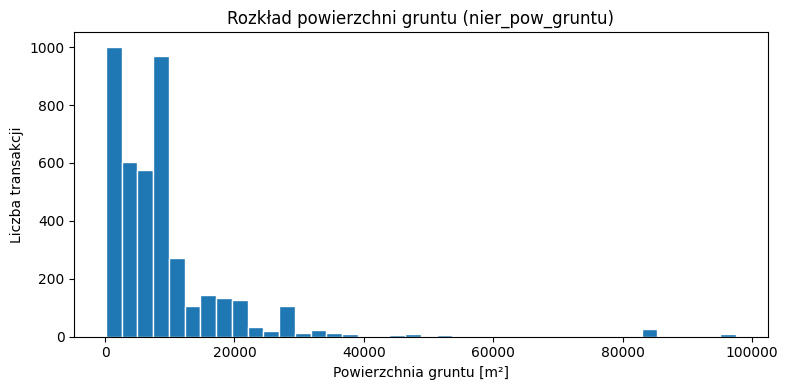

In [21]:
import matplotlib.pyplot as plt

pow_gruntu = pd.to_numeric(dane_epsg2180_lublin["nier_pow_gruntu"], errors="coerce").dropna()

plt.figure(figsize=(8, 4))
plt.hist(pow_gruntu, bins=40, edgecolor="white")
plt.title("Rozkład powierzchni gruntu (nier_pow_gruntu)")
plt.xlabel("Powierzchnia gruntu [m²]")
plt.ylabel("Liczba transakcji")
plt.tight_layout()
plt.show()

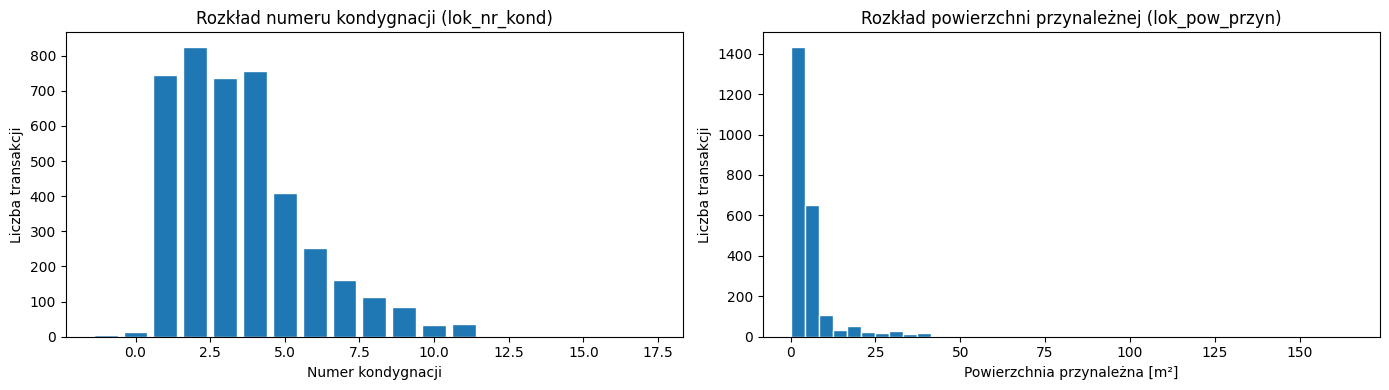

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

nr_kond = pd.to_numeric(dane_epsg2180_lublin["lok_nr_kond"], errors="coerce")
kond_counts = nr_kond.value_counts().sort_index()
axes[0].bar(kond_counts.index.astype(int), kond_counts.values, edgecolor="white")
axes[0].set_title("Rozkład numeru kondygnacji (lok_nr_kond)")
axes[0].set_xlabel("Numer kondygnacji")
axes[0].set_ylabel("Liczba transakcji")

pow_przyn = pd.to_numeric(dane_epsg2180_lublin["lok_pow_przyn"], errors="coerce").dropna()
axes[1].hist(pow_przyn, bins=40, edgecolor="white")
axes[1].set_title("Rozkład powierzchni przynależnej (lok_pow_przyn)")
axes[1].set_xlabel("Powierzchnia przynależna [m²]")
axes[1].set_ylabel("Liczba transakcji")

fig.tight_layout()
plt.show()

Zmienne te są wyraźnie prawoskośne. Dla zmiennej `nier_pow_gruntu` zastosowano imputację medianą.

Zmienną `lok_nr_kond` zimputowaną medianą liczoną dla dzielnicy w której znajduje się dane mieszkanie. Z reguły dzielnice mają podobną zabudowę i liczbę kondygnacji w budowlach.

Zmienna `lok_pow_przyn` zawiera informację o powierzchni pomieszczeń takich jak garaże, ogródki, piwnice itd. Jeżeli informacja ta nie została przypisana do mieszkania możemy założyć, że nie ma takich pomieszczeń, zatem została ona uzupełniona stałą 0.

In [23]:

for col in ("nier_pow_gruntu", "lok_nr_kond", "lok_pow_przyn"):
    dane_epsg2180_lublin[col] = pd.to_numeric(dane_epsg2180_lublin[col], errors="coerce")

dane_epsg2180_lublin["nier_pow_gruntu"] = dane_epsg2180_lublin["nier_pow_gruntu"].fillna(
    dane_epsg2180_lublin["nier_pow_gruntu"].median()
)

dane_epsg2180_lublin["lok_nr_kond"] = dane_epsg2180_lublin.groupby("dzielnica", dropna=False)[
    "lok_nr_kond"
].transform(lambda s: s.fillna(s.median()))
dane_epsg2180_lublin["lok_nr_kond"] = dane_epsg2180_lublin["lok_nr_kond"].fillna(
    dane_epsg2180_lublin["lok_nr_kond"].median()
)

dane_epsg2180_lublin["lok_pow_przyn"] = dane_epsg2180_lublin["lok_pow_przyn"].fillna(0)

Po wszyskich operacjach liczba wybrakowanych cech wygląda następująco:

In [24]:
dane_epsg2180_lublin.isna().sum()

tran_rodzaj_trans    0
tran_rodzaj_rynku    0
tran_sprzedajacy     0
tran_kupujacy        0
tran_cena_brutto     0
nier_prawo           0
nier_udzial          0
nier_pow_gruntu      0
lok_liczba_izb       0
lok_nr_kond          0
lok_pow_uzyt         0
lok_pow_przyn        0
dzielnica            0
Ulica                0
dok_miesiac          0
dok_rok              0
coord_x              0
coord_y              0
dtype: int64

## Typy danych
Kolejnym krokiem mającym na celu przygotować dane do dalszej analizy jest ustawienie odpowiednich typów danych.

Typy danych przed zmianą:

In [25]:
dane_epsg2180_lublin.dtypes

tran_rodzaj_trans        str
tran_rodzaj_rynku        str
tran_sprzedajacy         str
tran_kupujacy            str
tran_cena_brutto         str
nier_prawo               str
nier_udzial              str
nier_pow_gruntu      float64
lok_liczba_izb           str
lok_nr_kond          float64
lok_pow_uzyt             str
lok_pow_przyn        float64
dzielnica                str
Ulica                 object
dok_miesiac            int32
dok_rok                int32
coord_x              float64
coord_y              float64
dtype: object

Typy danych po zmianie:

In [26]:

dane_epsg2180_lublin["tran_cena_brutto"] = pd.to_numeric(dane_epsg2180_lublin["tran_cena_brutto"], errors="coerce")
dane_epsg2180_lublin["nier_pow_gruntu"] = pd.to_numeric(dane_epsg2180_lublin["nier_pow_gruntu"], errors="coerce")
dane_epsg2180_lublin["lok_pow_uzyt"] = pd.to_numeric(dane_epsg2180_lublin["lok_pow_uzyt"], errors="coerce")
dane_epsg2180_lublin["lok_pow_przyn"] = pd.to_numeric(dane_epsg2180_lublin["lok_pow_przyn"], errors="coerce")
dane_epsg2180_lublin["lok_nr_kond"] = pd.to_numeric(dane_epsg2180_lublin["lok_nr_kond"], errors="coerce")
dane_epsg2180_lublin["coord_x"] = pd.to_numeric(dane_epsg2180_lublin["coord_x"], errors="coerce")
dane_epsg2180_lublin["coord_y"] = pd.to_numeric(dane_epsg2180_lublin["coord_y"], errors="coerce")


dane_epsg2180_lublin["lok_liczba_izb"] = pd.to_numeric(dane_epsg2180_lublin["lok_liczba_izb"], errors="coerce").astype("Int8")
dane_epsg2180_lublin["dok_miesiac"] = pd.to_numeric(dane_epsg2180_lublin["dok_miesiac"], errors="coerce").astype("Int8")
dane_epsg2180_lublin["dok_rok"] = pd.to_numeric(dane_epsg2180_lublin["dok_rok"], errors="coerce").astype("Int16")


dane_epsg2180_lublin["tran_rodzaj_trans"] = dane_epsg2180_lublin["tran_rodzaj_trans"].astype("category")
dane_epsg2180_lublin["tran_rodzaj_rynku"] = dane_epsg2180_lublin["tran_rodzaj_rynku"].astype("category")
dane_epsg2180_lublin["tran_sprzedajacy"] = dane_epsg2180_lublin["tran_sprzedajacy"].astype("category")
dane_epsg2180_lublin["tran_kupujacy"] = dane_epsg2180_lublin["tran_kupujacy"].astype("category")
dane_epsg2180_lublin["nier_prawo"] = dane_epsg2180_lublin["nier_prawo"].astype("category")
dane_epsg2180_lublin["nier_udzial"] = dane_epsg2180_lublin["nier_udzial"].astype("category")
dane_epsg2180_lublin["dzielnica"] = dane_epsg2180_lublin["dzielnica"].astype("category")
dane_epsg2180_lublin["Ulica"] = dane_epsg2180_lublin["Ulica"].astype("category")

dane_epsg2180_lublin["dzielnica"] = dane_epsg2180_lublin["dzielnica"].cat.remove_unused_categories()

dane_epsg2180_lublin.dtypes

tran_rodzaj_trans    category
tran_rodzaj_rynku    category
tran_sprzedajacy     category
tran_kupujacy        category
tran_cena_brutto      float64
nier_prawo           category
nier_udzial          category
nier_pow_gruntu       float64
lok_liczba_izb           Int8
lok_nr_kond           float64
lok_pow_uzyt          float64
lok_pow_przyn         float64
dzielnica            category
Ulica                category
dok_miesiac              Int8
dok_rok                 Int16
coord_x               float64
coord_y               float64
dtype: object

In [27]:
dane_epsg2180_lublin.to_parquet("data/clean_data.parquet", engine="pyarrow", index=False)